# 📊 Notebook 1: Análisis Exploratorio de Datos (EDA)
## Dataset: Medical Cost Personal Dataset

**Objetivo:** Comprender la distribución, correlaciones, valores faltantes y sesgos del dataset de costos médicos.

**Variable objetivo:** `charges` (costos médicos individuales)

**Variables:**
- `age`: edad del beneficiario
- `sex`: género (female/male)
- `bmi`: índice de masa corporal
- `children`: número de hijos cubiertos
- `smoker`: fumador (yes/no)
- `region`: región residencial en EE.UU.
- `charges`: costos médicos (TARGET)

In [18]:
# ─────────────────────────────────────────
# IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 1. Carga del Dataset

In [19]:
# Carga del dataset desde la carpeta raw
df = pd.read_csv('../data/raw/insurance.csv')

print(f'📦 Shape del dataset: {df.shape}')
print(f'📋 Columnas: {list(df.columns)}')
df.head(10)

📦 Shape del dataset: (1338, 7)
📋 Columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## 2. Información General del Dataset

In [20]:
# ─────────────────────────────────────────
# TIPOS DE DATOS Y DIMENSIONES
# ─────────────────────────────────────────
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [21]:
# Estadísticas descriptivas
print('='*60)
print('ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas')
print('='*60)
df.describe().round(2)

ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [22]:
# Estadísticas variables categóricas
print('='*60)
print('ESTADÍSTICAS - Variables Categóricas')
print('='*60)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n📌 {col.upper()}:')
    print(df[col].value_counts())
    print(f'   Proporción (%):')
    print((df[col].value_counts(normalize=True)*100).round(2))

ESTADÍSTICAS - Variables Categóricas

📌 SEX:
sex
male      676
female    662
Name: count, dtype: int64
   Proporción (%):
sex
male      50.52
female    49.48
Name: proportion, dtype: float64

📌 SMOKER:
smoker
no     1064
yes     274
Name: count, dtype: int64
   Proporción (%):
smoker
no     79.52
yes    20.48
Name: proportion, dtype: float64

📌 REGION:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
   Proporción (%):
region
southeast    27.20
southwest    24.29
northwest    24.29
northeast    24.22
Name: proportion, dtype: float64


## 3. Análisis de Valores Faltantes

✅ ¡No hay valores faltantes en el dataset!


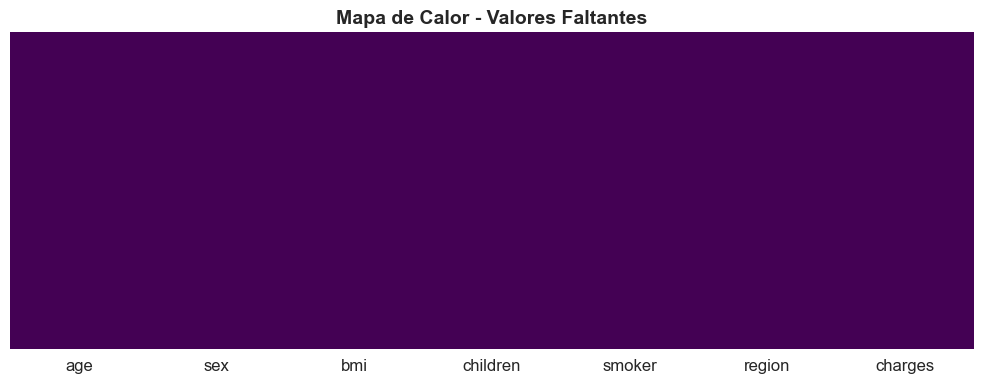


💡 CONCLUSIÓN: El dataset no presenta valores faltantes, lo que facilita el preprocesamiento.


In [23]:
# ─────────────────────────────────────────
# IDENTIFICACIÓN DE VALORES FALTANTES
# ─────────────────────────────────────────
missing = pd.DataFrame({
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje_%': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valores_Faltantes'] > 0]

if missing.empty:
    print('✅ ¡No hay valores faltantes en el dataset!')
else:
    print('⚠️ Valores faltantes encontrados:')
    display(missing)

# Visualización de nulos (heatmap)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Mapa de Calor - Valores Faltantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 CONCLUSIÓN: El dataset no presenta valores faltantes, lo que facilita el preprocesamiento.')

## 4. Distribución de Variables Numéricas

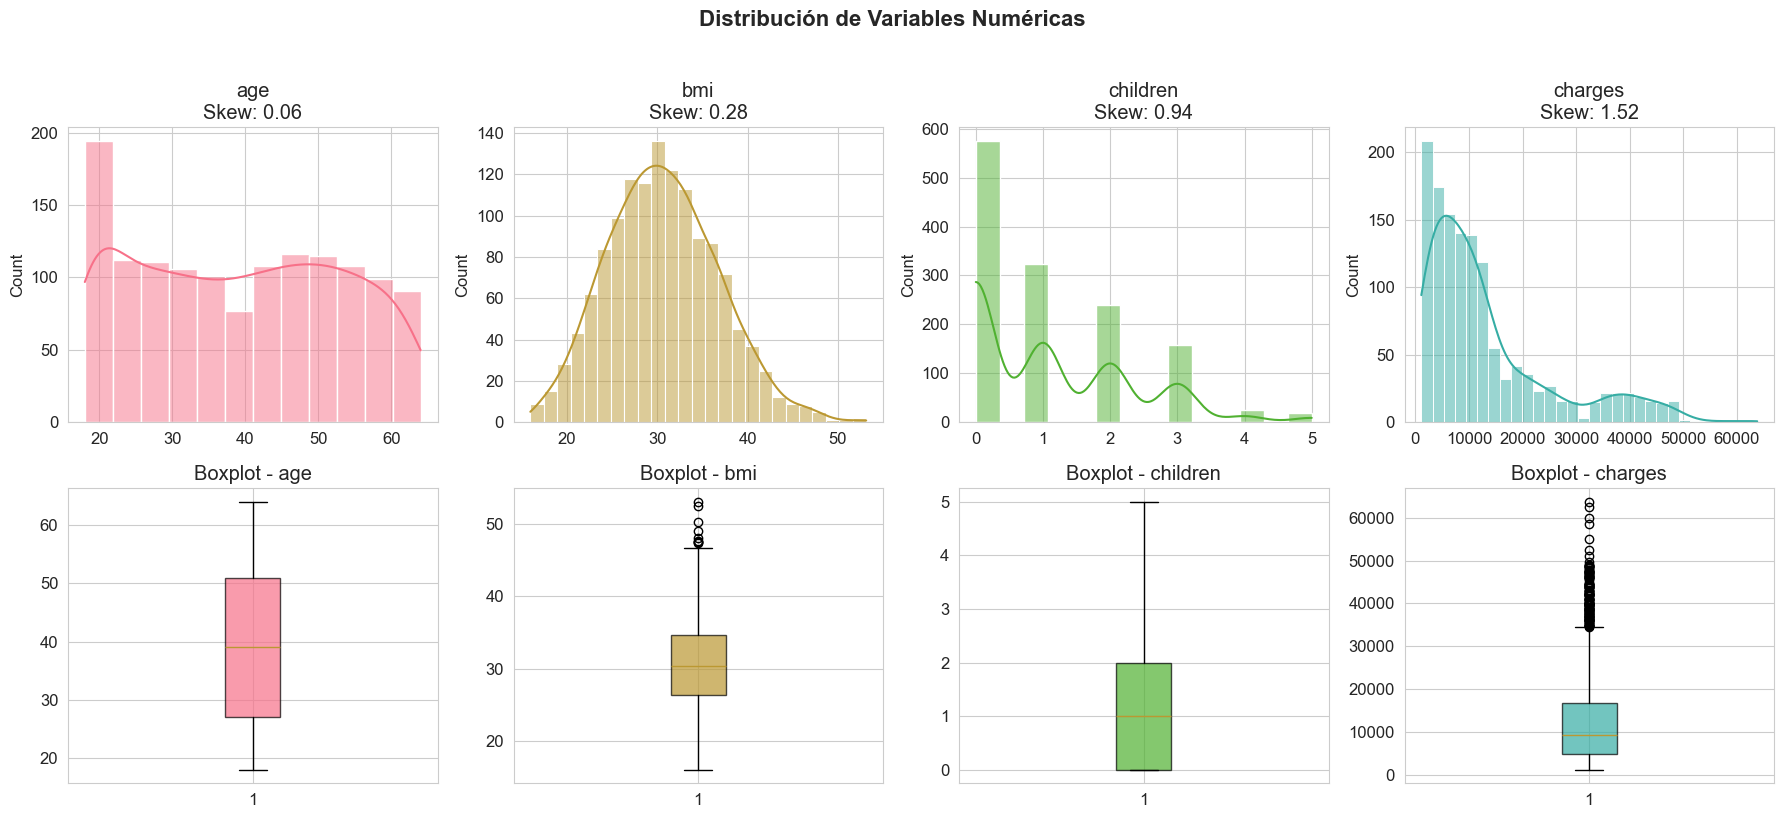


📊 ANÁLISIS DE SESGO (SKEWNESS):
  age         : skew =  0.056  →   Simétrica
  bmi         : skew =  0.284  →   Simétrica
  children    : skew =  0.938  →   Moderadamente sesgada
  charges     : skew =  1.516  →   Altamente sesgada


In [33]:
# ─────────────────────────────────────────
# DISTRIBUCIÓN Y SESGO (SKEWNESS)
# ─────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 8))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(num_cols):
    # Histograma con KDE
    sns.histplot(df[col], kde=True, ax=axes[0, i], color=sns.color_palette('husl')[i])
    axes[0, i].set_title(f'{col}\nSkew: {df[col].skew():.2f}')
    axes[0, i].set_xlabel('')
    
    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor=sns.color_palette('husl')[i], alpha=0.7))
    axes[1, i].set_title(f'Boxplot - {col}')

plt.tight_layout()
plt.savefig('../data/processed/num_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Reporte de sesgo
print('\n📊 ANÁLISIS DE SESGO (SKEWNESS):')
for col in num_cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        nivel = ' Simétrica'
    elif abs(skew) < 1:
        nivel = ' Moderadamente sesgada'
    else:
        nivel = ' Altamente sesgada'
    print(f'  {col:12s}: skew = {skew:6.3f}  →  {nivel}')

## 5. Análisis de la Variable Objetivo (charges)

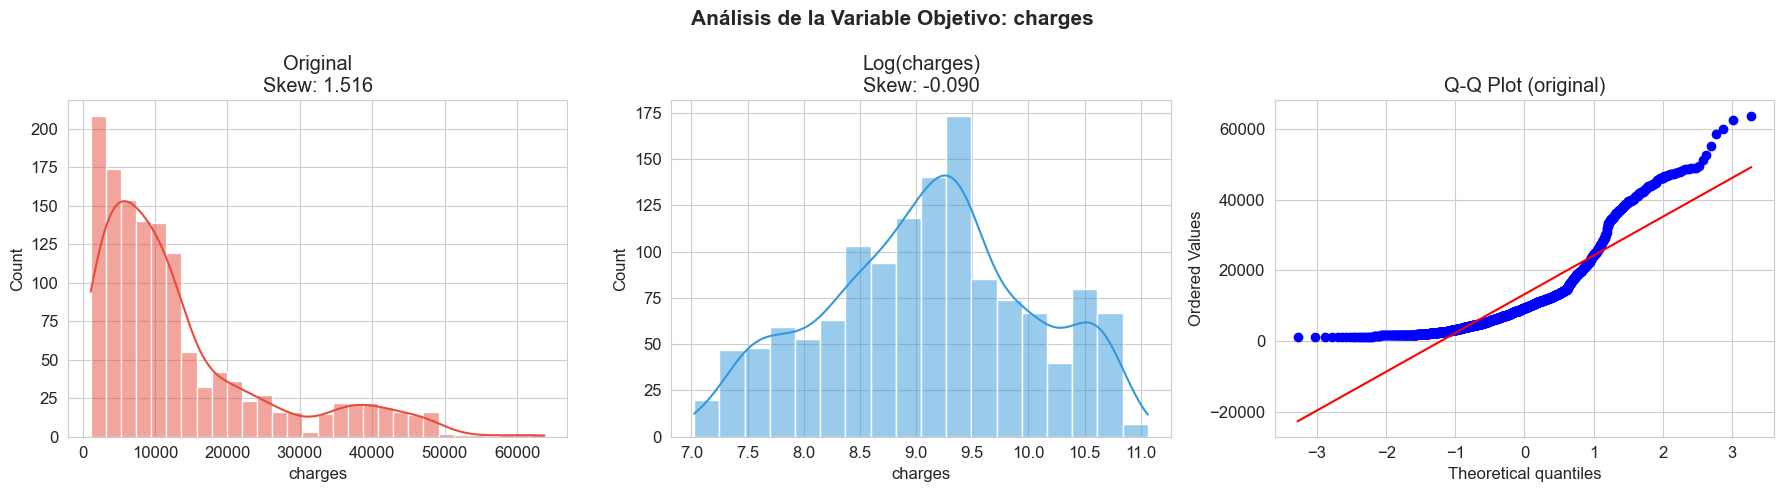

💡 charges original: Skewness = 1.516 → Distribución multimodal y sesgada a la derecha
💡 log(charges): Skewness = -0.090 → Más simétrica, mejor para modelos lineales


In [25]:
# ─────────────────────────────────────────
# TARGET: charges — distribución y transformación
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de la Variable Objetivo: charges', fontsize=15, fontweight='bold')

# Distribución original
sns.histplot(df['charges'], kde=True, ax=axes[0], color='#e74c3c')
axes[0].set_title(f'Original\nSkew: {df["charges"].skew():.3f}')

# Distribución log-transformada
log_charges = np.log1p(df['charges'])
sns.histplot(log_charges, kde=True, ax=axes[1], color='#3498db')
axes[1].set_title(f'Log(charges)\nSkew: {log_charges.skew():.3f}')

# Q-Q Plot
stats.probplot(df['charges'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (original)')

plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'💡 charges original: Skewness = {df["charges"].skew():.3f} → Distribución multimodal y sesgada a la derecha')
print(f'💡 log(charges): Skewness = {log_charges.skew():.3f} → Más simétrica, mejor para modelos lineales')

## 6. Análisis de Variables Categóricas vs Charges

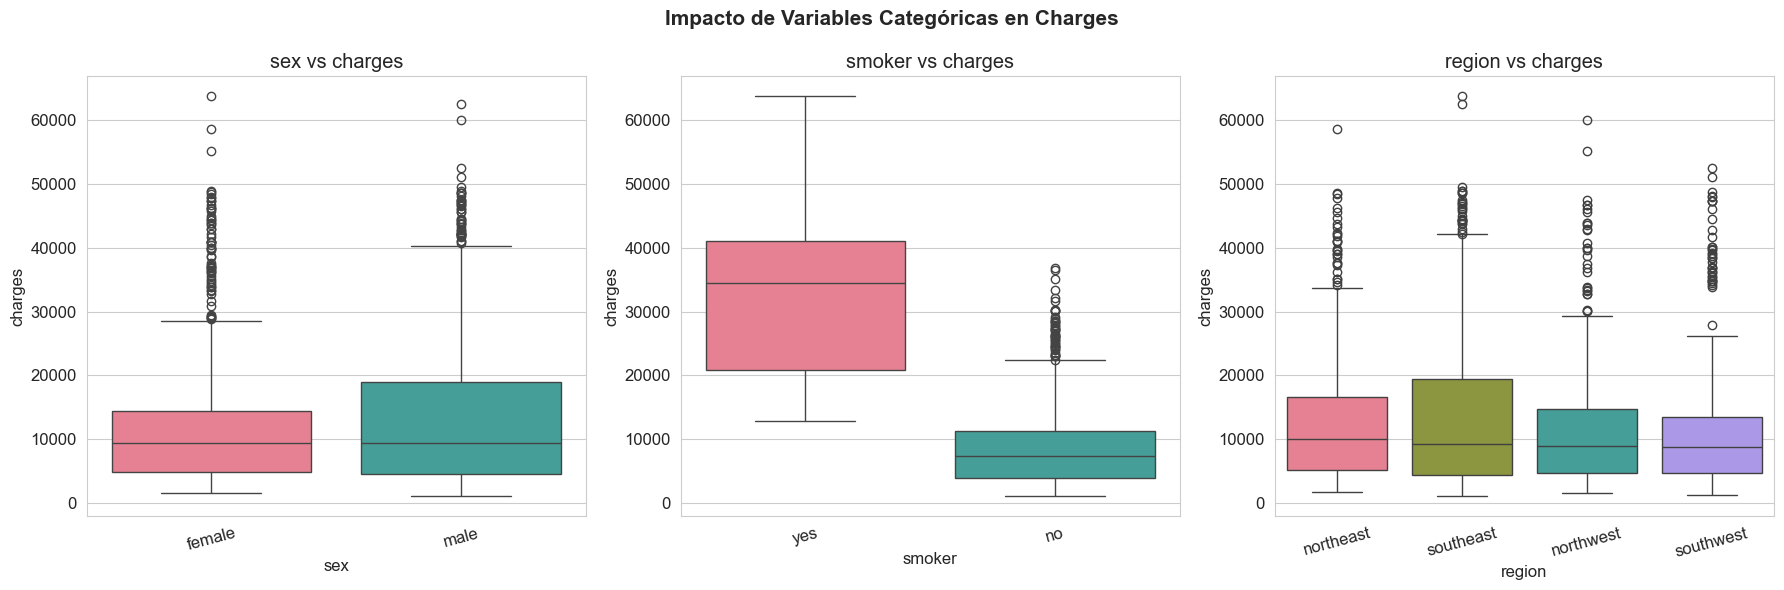


📊 PRUEBA ANOVA - Significancia estadística:
  sex       : F=4.40, p=0.0361  →  ✅ Significativa
  smoker    : F=2177.61, p=0.0000  →  ✅ Significativa
  region    : F=2.97, p=0.0309  →  ✅ Significativa


In [26]:
# ─────────────────────────────────────────
# VARIABLES CATEGÓRICAS VS TARGET
# ─────────────────────────────────────────
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impacto de Variables Categóricas en Charges', fontsize=15, fontweight='bold')

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['charges'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='charges', order=order, ax=axes[i],
                palette='husl')
    axes[i].set_title(f'{col} vs charges')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../data/processed/categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

# ANOVA test para significancia
print('\n📊 PRUEBA ANOVA - Significancia estadística:')
for col in cat_cols:
    groups = [group['charges'].values for name, group in df.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '✅ Significativa' if p_val < 0.05 else '❌ No significativa'
    print(f'  {col:10s}: F={f_stat:.2f}, p={p_val:.4f}  →  {sig}')

## 7. Análisis de Variables Numéricas vs Charges

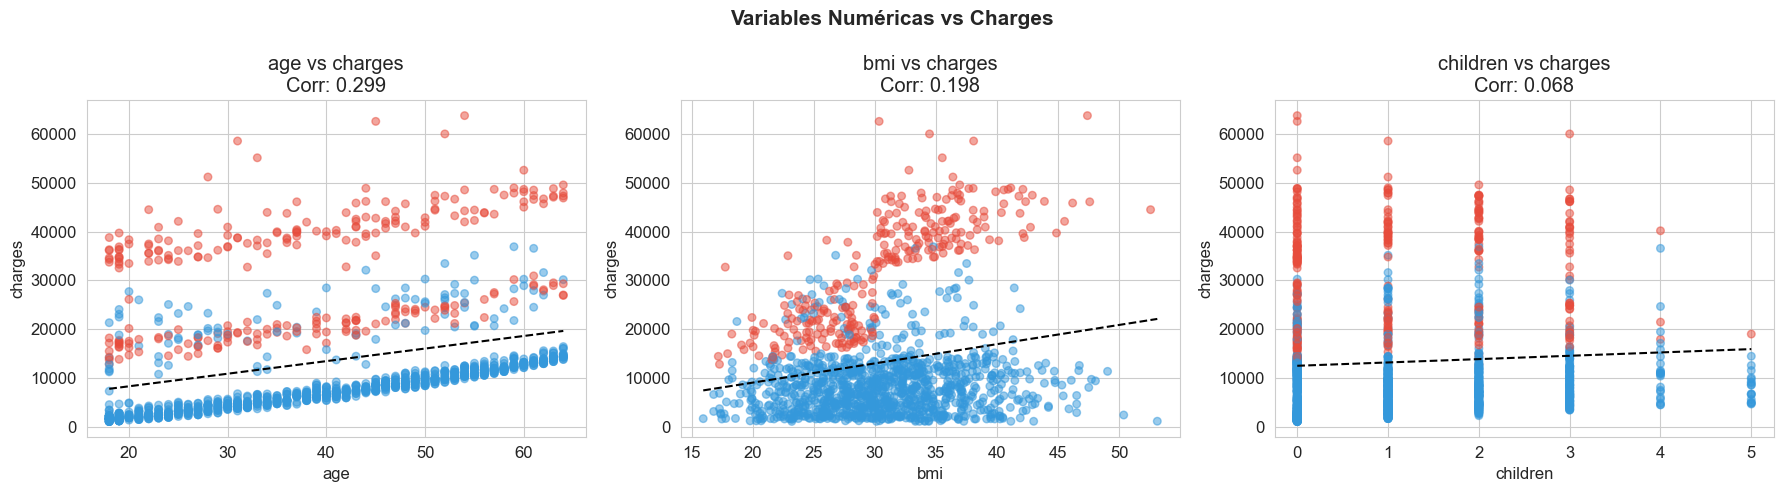

In [27]:
# ─────────────────────────────────────────
# SCATTER PLOTS: numéricas vs target
# ─────────────────────────────────────────
num_features = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Variables Numéricas vs Charges', fontsize=15, fontweight='bold')

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['charges'],
                    c=df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'}),
                    alpha=0.5, s=30)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges')
    axes[i].set_title(f'{col} vs charges\n(rojo=fumador)')
    
    # Línea de regresión
    z = np.polyfit(df[col], df['charges'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df[col]), p(sorted(df[col])), 'k--', linewidth=1.5, label='Tendencia')
    
    corr = df[col].corr(df['charges'])
    axes[i].set_title(f'{col} vs charges\nCorr: {corr:.3f}')

plt.tight_layout()
plt.savefig('../data/processed/numeric_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Matriz de Correlación

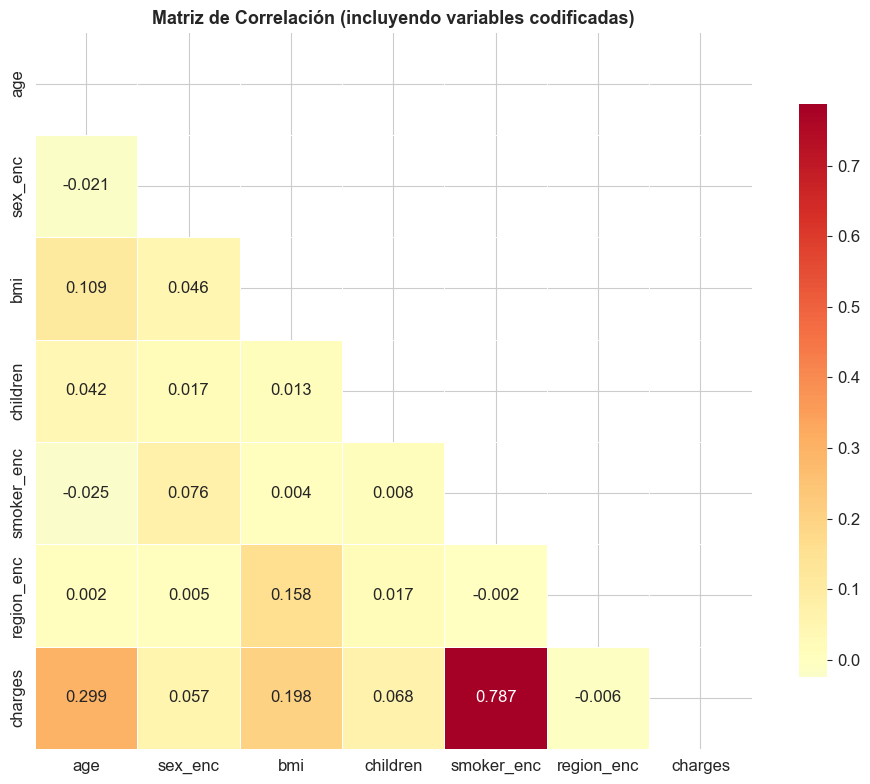


📊 CORRELACIÓN CON charges:
  smoker_enc     : +0.787  ███████████████
  age            : +0.299  █████
  bmi            : +0.198  ███
  children       : +0.068  █
  sex_enc        : +0.057  █
  region_enc     : -0.006  


In [28]:
# ─────────────────────────────────────────
# CORRELACIÓN — Codificación temporal para visualizar
# ─────────────────────────────────────────
df_corr = df.copy()
df_corr['sex_enc'] = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['smoker_enc'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
df_corr['region_enc'] = pd.Categorical(df_corr['region']).codes

cols_corr = ['age', 'sex_enc', 'bmi', 'children', 'smoker_enc', 'region_enc', 'charges']
corr_matrix = df_corr[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdYlBu_r', center=0, square=True,
            linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación (incluyendo variables codificadas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 CORRELACIÓN CON charges:')
corr_target = corr_matrix['charges'].drop('charges').sort_values(key=abs, ascending=False)
for feat, corr in corr_target.items():
    bar = '█' * int(abs(corr) * 20)
    print(f'  {feat:15s}: {corr:+.3f}  {bar}')

## 9. Análisis de Outliers

📊 ANÁLISIS DE OUTLIERS (Método IQR):
-------------------------------------------------------
  age       :    0 outliers (0.0%)  |  rango: [-9.0, 87.0]
  bmi       :    9 outliers (0.7%)  |  rango: [13.7, 47.3]
  children  :    0 outliers (0.0%)  |  rango: [-3.0, 5.0]
  charges   :  139 outliers (10.4%)  |  rango: [-13109.2, 34489.4]


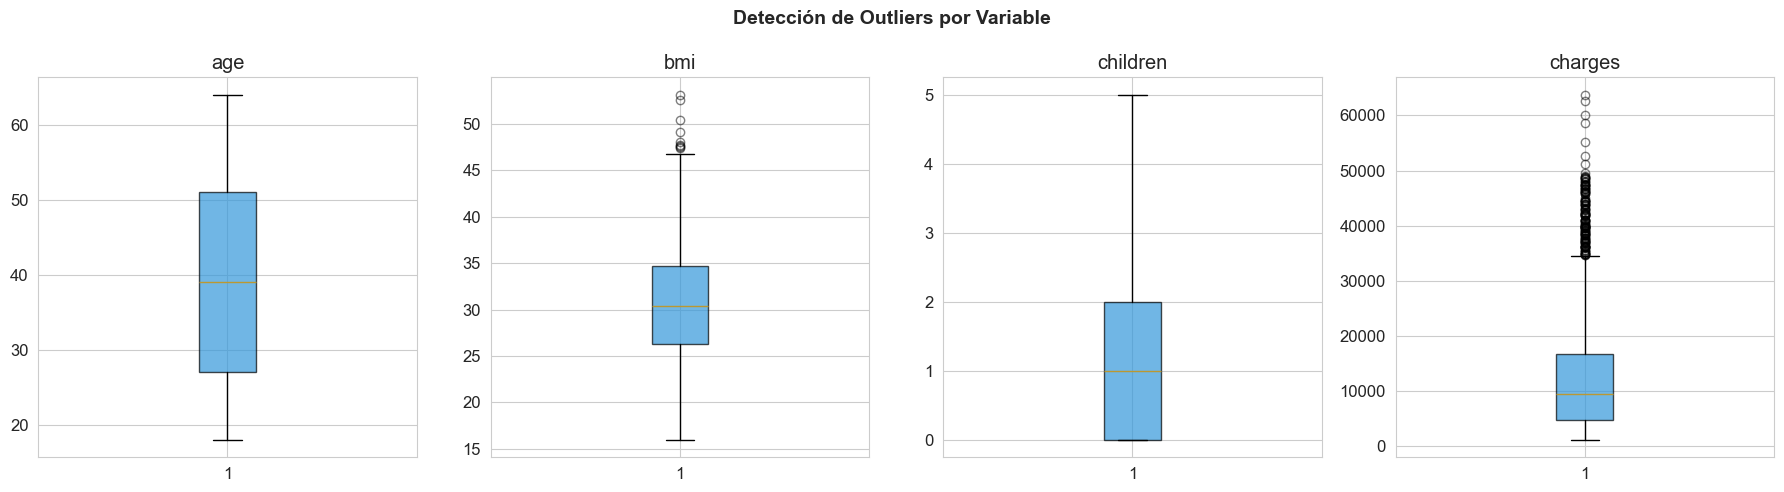

In [29]:
# ─────────────────────────────────────────
# DETECCIÓN DE OUTLIERS (IQR)
# ─────────────────────────────────────────
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

print('📊 ANÁLISIS DE OUTLIERS (Método IQR):')
print('-'*55)
for col in num_cols:
    n_out, lb, ub = detect_outliers_iqr(df, col)
    pct = n_out / len(df) * 100
    print(f'  {col:10s}: {n_out:4d} outliers ({pct:.1f}%)  |  rango: [{lb:.1f}, {ub:.1f}]')

# Visualización
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
fig.suptitle('Detección de Outliers por Variable', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.7),
                   flierprops=dict(marker='o', color='#e74c3c', alpha=0.5))
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../data/processed/outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Pairplot y Análisis por Segmentos Clave

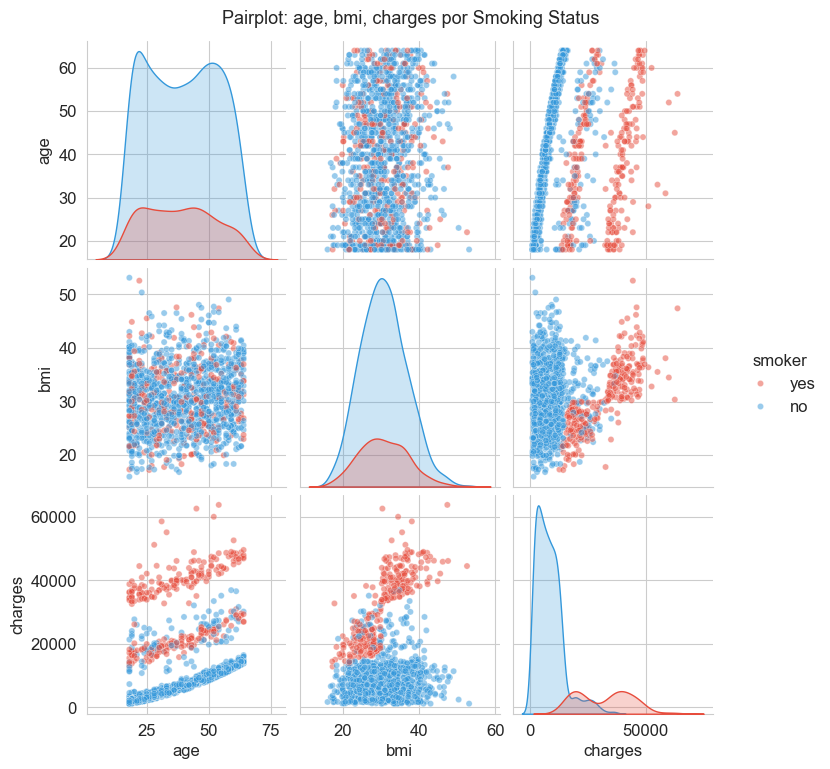

💡 Los fumadores tienen costos significativamente más altos independientemente de edad y BMI


In [30]:
# ─────────────────────────────────────────
# PAIRPLOT — Variables más relevantes
# ─────────────────────────────────────────
pairplot_cols = ['age', 'bmi', 'charges', 'smoker']
g = sns.pairplot(df[pairplot_cols], hue='smoker',
                 palette={'yes': '#e74c3c', 'no': '#3498db'},
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Pairplot: age, bmi, charges por Smoking Status', y=1.02, fontsize=13)
plt.savefig('../data/processed/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Los fumadores tienen costos significativamente más altos independientemente de edad y BMI')

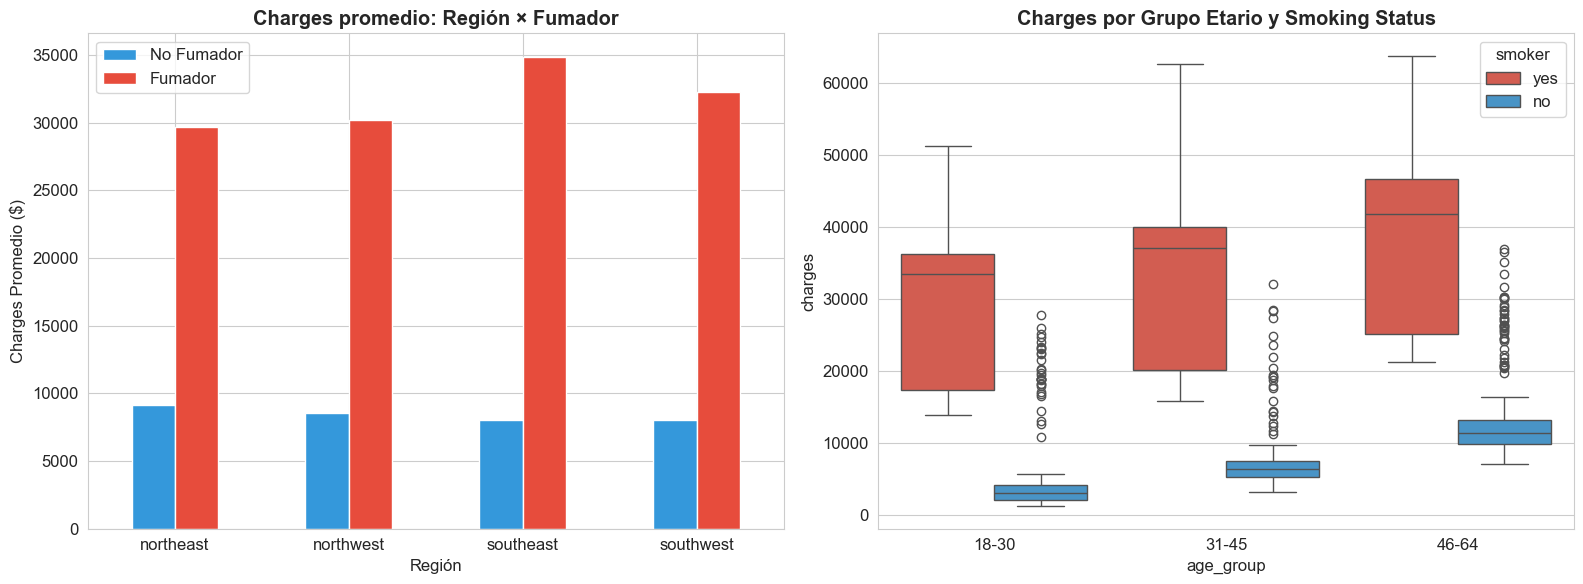

In [31]:
# ─────────────────────────────────────────
# ANÁLISIS SEGMENTADO: smoker + region + age
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Charges promedio por región y smoking
pivot = df.groupby(['region', 'smoker'])['charges'].mean().unstack()
pivot.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Charges promedio: Región × Fumador', fontweight='bold')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Charges Promedio ($)')
axes[0].legend(['No Fumador', 'Fumador'])
axes[0].tick_params(axis='x', rotation=0)

# Charges por grupo etario
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 45, 64], labels=['18-30', '31-45', '46-64'])
sns.boxplot(data=df, x='age_group', y='charges', hue='smoker',
            palette={'yes': '#e74c3c', 'no': '#3498db'}, ax=axes[1])
axes[1].set_title('Charges por Grupo Etario y Smoking Status', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/segmented_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Limpiar columna temporal
df.drop(columns=['age_group'], inplace=True)

## 11. 📝 Conclusiones del EDA

### Hallazgos Principales:

1. **Valores Faltantes:** El dataset está completo (0 valores nulos), no requiere imputación.

2. **Variable Objetivo (`charges`):**
   - Distribución fuertemente sesgada a la derecha (skew ≈ 1.5)
   - Distribución multimodal (3 picos) sugiere subpoblaciones
   - La transformación log normaliza considerablemente la distribución

3. **Variable más Relevante: `smoker`**
   - Los fumadores pagan en promedio 3-4x más que no fumadores
   - ANOVA confirma diferencia estadísticamente significativa (p < 0.001)
   - Mayor correlación con charges (~0.79)

4. **`age` y `bmi`:**
   - Correlación positiva moderada con charges
   - La interacción `bmi × smoker` puede ser un predictor poderoso

5. **Outliers:**
   - Presentes principalmente en `charges` y `bmi`
   - Los valores extremos de `charges` corresponden a fumadores con BMI alto
   - Se mantendrán para no eliminar segmentos válidos

6. **Variables Categóricas:**
   - `sex` y `region` tienen menor impacto en charges
   - Las 4 regiones tienen distribuciones similares de charges

### Recomendaciones para el Preprocesamiento:
- Aplicar transformación log a `charges` para modelos lineales
- Crear feature de interacción `bmi_smoker`
- Codificar variables categóricas con One-Hot Encoding
- Escalar variables numéricas con StandardScaler

In [32]:
# Guardar resumen del EDA
eda_summary = {
    'n_registros': len(df),
    'n_columnas': len(df.columns),
    'valores_nulos': int(df.isnull().sum().sum()),
    'charges_media': float(df['charges'].mean()),
    'charges_mediana': float(df['charges'].median()),
    'charges_skew': float(df['charges'].skew()),
    'pct_fumadores': float((df['smoker']=='yes').mean()*100)
}
import json
with open('../data/processed/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)

print('✅ EDA completado. Resumen guardado en /data/processed/eda_summary.json')
print('\n📊 RESUMEN:')
for k, v in eda_summary.items():
    print(f'  {k}: {v}')

✅ EDA completado. Resumen guardado en /data/processed/eda_summary.json

📊 RESUMEN:
  n_registros: 1338
  n_columnas: 7
  valores_nulos: 0
  charges_media: 13270.422265141257
  charges_mediana: 9382.033
  charges_skew: 1.5158796580240388
  pct_fumadores: 20.47832585949178
